# Movie Recommender — NLP Pipeline

Content-based movie recommendation using **TF-IDF** + **cosine similarity** over
each movie's overview, genres, and tagline.

**Pipeline:** load raw TMDB metadata -> clean & merge text fields -> NLP
preprocessing (stopword removal + lemmatization) -> TF-IDF vectorization ->
similarity search -> persist artifacts for the FastAPI backend.

This notebook mirrors `scripts/train_model.py` (the version actually run in
production) with extra EDA and inline explanation. The cleaning function
defined below is kept in sync with `common/preprocess.py`, which is what
both the training script and the API (`backend/main.py`, for the free-text
`/recommend/vibe` endpoint) actually import at runtime.


In [1]:
import ast
import re

import matplotlib.pyplot as plt
import nltk
import numpy as np
import pandas as pd
import seaborn as sns
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import linear_kernel

import warnings
warnings.filterwarnings("ignore")

for pkg in ("stopwords", "wordnet", "omw-1.4"):
    try:
        nltk.data.find(f"corpora/{pkg}")
    except LookupError:
        nltk.download(pkg, quiet=True)

## 1. Load & inspect raw data

In [2]:
df = pd.read_csv("../data/movies_metadata.csv", low_memory=False)
print(df.shape)
df.head(3)

(45466, 24)


,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",...,1995-10-30,373554033.0,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415.0
1,False,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",NaN,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,...,1995-12-15,262797249.0,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0
2,False,"{'id': 119050, 'name': 'Grumpy Old Men Collect...",0,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",NaN,15602,tt0113228,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,...,1995-12-22,0.0,101.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Still Yelling. Still Fighting. Still Ready for...,Grumpier Old Men,False,6.5,92.0


In [3]:
df.isnull().sum().sort_values(ascending=False).head(10)

belongs_to_collection    40972
homepage                 37684
tagline                  25054
overview                   954
poster_path                386
runtime                    263
status                      87
release_date                87
imdb_id                     17
original_language           11
dtype: int64

In [4]:
df = df.drop_duplicates().reset_index(drop=True)
print(f"After de-dup: {df.shape}")

After de-dup: (45449, 24)


## 2. Keep the fields the model actually needs

In [5]:
df = df[["title", "overview", "genres", "tagline", "vote_count", "vote_average", "popularity"]]
df = df.dropna(subset=["title"]).reset_index(drop=True)
df["overview"] = df["overview"].fillna("")
df["tagline"] = df["tagline"].fillna("")
df.isnull().sum()

title           0
overview        0
genres          0
tagline         0
vote_count      0
vote_average    0
popularity      0
dtype: int64

## 3. Parse genres

`genres` ships as a stringified list of dicts, e.g.
`"[{'id': 16, 'name': 'Animation'}, {'id': 35, 'name': 'Comedy'}]"`.
Parse it into a plain space-joined string of genre names.

In [6]:
def parse_genres(raw: str) -> str:
    try:
        return " ".join(g["name"] for g in ast.literal_eval(raw))
    except (ValueError, SyntaxError):
        return ""

df["genres_parsed"] = df["genres"].apply(parse_genres)
df[["title", "genres_parsed"]].head()

,title,genres_parsed
0,Toy Story,Animation Comedy Family
1,Jumanji,Adventure Fantasy Family
2,Grumpier Old Men,Romance Comedy
3,Waiting to Exhale,Comedy Drama Romance
4,Father of the Bride Part II,Comedy


## 4. Build the `tags` field

Overview + genres + tagline, combined into one bag of text per movie.
Genres are weighted **2x** so a movie's genre carries real weight against a
full paragraph overview when TF-IDF scores similarity - otherwise the much
longer overview text dominates and genre barely moves the similarity score.

In [7]:
df["tags"] = (
    df["overview"] + " "
    + df["genres_parsed"] + " " + df["genres_parsed"] + " "
    + df["tagline"]
)
df[["title", "tags"]].head(2)

,title,tags
0,Toy Story,"Led by Woody, Andy's toys live happily in his ..."
1,Jumanji,When siblings Judy and Peter discover an encha...


## 5. Text cleaning: lowercase, strip noise, remove stopwords, lemmatize

> **Bug fixed vs. the original draft:** lemmatized tokens were previously
> assigned to a variable that was never returned (`word` vs `words`), so
> lemmatization silently never ran. Also dropped short tokens (len <= 2,
> mostly punctuation debris and stray initials) which were inflating the
> vocabulary without adding signal.

In [8]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def clean_text(text: str) -> str:
    text = str(text).lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    tokens = text.split()
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return " ".join(tokens)

df["tags"] = df["tags"].apply(clean_text)
df = df[df["tags"].str.strip().str.len() > 0].reset_index(drop=True)
df[["title", "tags"]].head(2)

,title,tags
0,Toy Story,led woody andy toy live happily room andy birt...
1,Jumanji,sibling judy peter discover enchanted board ga...


## 6. Quick EDA - vocabulary & genre distribution

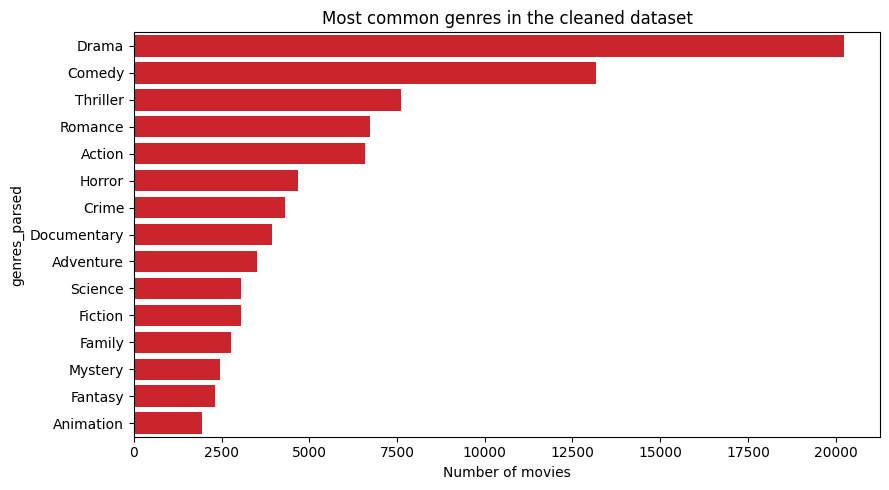

In [9]:
top_genres = df["genres_parsed"].str.split().explode().value_counts().head(15)

plt.figure(figsize=(9, 5))
sns.barplot(x=top_genres.values, y=top_genres.index, color="#e50914")
plt.title("Most common genres in the cleaned dataset")
plt.xlabel("Number of movies")
plt.tight_layout()
plt.show()

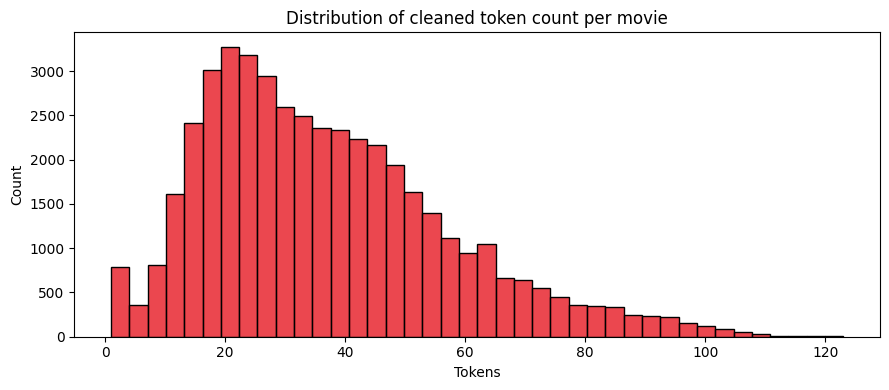

In [10]:
tag_lengths = df["tags"].str.split().apply(len)
plt.figure(figsize=(9, 4))
sns.histplot(tag_lengths, bins=40, color="#e50914")
plt.title("Distribution of cleaned token count per movie")
plt.xlabel("Tokens")
plt.tight_layout()
plt.show()

## 7. TF-IDF vectorization

Unigrams + bigrams, capped at 50k features. Bigrams let phrases like
`space travel` or `high school` carry more signal than their component
words alone.

In [11]:
vectorizer = TfidfVectorizer(max_features=50000, ngram_range=(1, 2))
tfidf_matrix = vectorizer.fit_transform(df["tags"])
print(f"TF-IDF matrix shape: {tfidf_matrix.shape}")

TF-IDF matrix shape: (45183, 50000)


## 8. Similarity search

scikit-learn's `TfidfVectorizer` output is already L2-normalized, so a plain
dot product **is** cosine similarity - no need for the heavier
`cosine_similarity` call per query. `np.argpartition` also avoids a full
sort across 45k+ rows when we only need the top-N matches.

In [12]:
title_indices = pd.Series(df.index, index=df["title"])
title_indices = title_indices[~title_indices.index.duplicated(keep="first")]

def recommend(title: str, n: int = 10):
    if title not in title_indices:
        return f"'{title}' not found in the local dataset."

    idx = title_indices[title]
    scores = linear_kernel(tfidf_matrix[idx], tfidf_matrix).ravel()

    k = min(n + 1, len(scores))
    top_idx = np.argpartition(-scores, k - 1)[:k]
    top_idx = top_idx[np.argsort(-scores[top_idx])]
    top_idx = [i for i in top_idx if i != idx][:n]

    return pd.DataFrame({
        "title": df["title"].iloc[top_idx].values,
        "similarity": scores[top_idx].round(3),
    })

recommend("Toy Story")

,title,similarity
0,Toy Story 2,0.480
1,Toy Story 3,0.401
2,Superstar Goofy,0.346
3,Small Fry,0.275
4,Banana,0.267
5,Botsman i Popugay,0.254
6,Lorenzo,0.248
7,The Emoji Movie,0.237
8,The 40 Year Old Virgin,0.232
9,Moomins on the Riviera,0.228


In [13]:
recommend("The Dark Knight")

,title,similarity
0,The Dark Knight Rises,0.335
1,İtirazım Var,0.332
2,Mord in Eberswalde,0.270
3,Pitbull,0.261
4,Bablo,0.261
5,Gangsters,0.255
6,Twelve,0.249
7,Initial D,0.234
8,The Last Bullet,0.234
9,Revenge of the Green Dragons,0.233


## 9. Persist artifacts for the FastAPI backend

In [14]:
import pickle
from pathlib import Path

MODELS_DIR = Path("../models")
MODELS_DIR.mkdir(exist_ok=True)

slim_df = df[["title", "overview", "genres_parsed", "vote_count", "vote_average", "popularity"]] \
    .rename(columns={"genres_parsed": "genres"})

slim_df.to_pickle(MODELS_DIR / "df.pkl")
with open(MODELS_DIR / "tfidf_vectorizer.pkl", "wb") as f:
    pickle.dump(vectorizer, f)
with open(MODELS_DIR / "tfidf_matrix.pkl", "wb") as f:
    pickle.dump(tfidf_matrix, f)
with open(MODELS_DIR / "title_indices.pkl", "wb") as f:
    pickle.dump(title_indices, f)

print("Saved: df.pkl, tfidf_vectorizer.pkl, tfidf_matrix.pkl, title_indices.pkl")

Saved: df.pkl, tfidf_vectorizer.pkl, tfidf_matrix.pkl, title_indices.pkl


## Next steps / possible extensions

Two of these were already carried into the API layer (`backend/main.py`) rather than staying notebook-only:

- **Hybrid ranking** — content similarity blended with a normalized `popularity`/`vote_count` signal (`alpha` parameter), so results are similar *and* worth watching, not just lexically close.
- **Free-text search** — the fitted vectorizer transforms an arbitrary query string into the same space, powering `/recommend/vibe` with no separate embedding model.

Still open:

- Swap TF-IDF for sentence embeddings (e.g. `all-MiniLM-L6-v2`) to capture semantic similarity beyond shared vocabulary.
- Track click-through on recommendations to build a lightweight feedback loop and tune `alpha` per user.
